# Policy Dataset Viewer
Loads all extracted policy files, shows per-source counts, merges into a combined dataset, and outputs statistics.

In [ ]:
import json
import os
import pandas as pd
from pathlib import Path

EXTRACTED_DIR = Path("../../extracted")
COMBINED_OUT  = EXTRACTED_DIR / "combined_policies.json"

## 1. Per-source policy counts

In [2]:
source_files = sorted(EXTRACTED_DIR.glob("*.json"))
source_files = [f for f in source_files if f.name != "combined_policies.json"]

counts = []
for fp in source_files:
    policies = json.loads(fp.read_text(encoding="utf-8"))
    counts.append({"source": fp.stem, "policies": len(policies)})

df_counts = pd.DataFrame(counts).sort_values("policies", ascending=False).reset_index(drop=True)
df_counts.loc[len(df_counts)] = {"source": "TOTAL", "policies": df_counts["policies"].sum()}
df_counts

,source,policies
0,OWASP_ASVS,429
1,NIST_AI_RMF,122
2,OWASP_LLM_Top10,90
3,CWE_Top25,85
4,OWASP_AI_Agent_Security,55
5,NIST_SP800218,48
6,PaloAlto_GenAI_Risk,40
7,TOTAL,869


## 2. Merge into combined dataset

In [3]:
all_policies = []
for fp in source_files:
    policies = json.loads(fp.read_text(encoding="utf-8"))
    for p in policies:
        p["source"] = fp.stem
    all_policies.extend(policies)

COMBINED_OUT.write_text(
    json.dumps(all_policies, indent=2, ensure_ascii=False),
    encoding="utf-8"
)
print(f"Saved {len(all_policies)} policies → {COMBINED_OUT}")

Saved 869 policies → ../extracted/combined_policies.json


## 3. Statistics

In [4]:
df = pd.DataFrame(all_policies)

print("=== Overview ===")
print(f"Total policies   : {len(df)}")
print(f"Sources          : {df['source'].nunique()}")
print(f"With definition  : {df['definition'].apply(lambda x: len(x) > 0).sum()} ({df['definition'].apply(lambda x: len(x) > 0).mean():.0%})")
print(f"With scope       : {df['scope'].notna().sum()} ({df['scope'].notna().mean():.0%})")
print(f"With reference   : {df['reference'].apply(lambda x: len(x) > 0).sum()} ({df['reference'].apply(lambda x: len(x) > 0).mean():.0%})")
print()

print("=== Policy description length ===")
desc_len = df["policy_description"].str.len()
print(desc_len.describe().rename("chars").to_string())
print()

print("=== Policies per source ===")
print(df["source"].value_counts().to_string())

=== Overview ===
Total policies   : 869
Sources          : 7
With definition  : 50 (6%)
With scope       : 303 (35%)
With reference   : 835 (96%)

=== Policy description length ===
count     869.000000
mean      187.242808
std       110.793180
min        25.000000
25%       112.000000
50%       166.000000
75%       233.000000
max      1123.000000

=== Policies per source ===
source
OWASP_ASVS                 429
NIST_AI_RMF                122
OWASP_LLM_Top10             90
CWE_Top25                   85
OWASP_AI_Agent_Security     55
NIST_SP800218               48
PaloAlto_GenAI_Risk         40


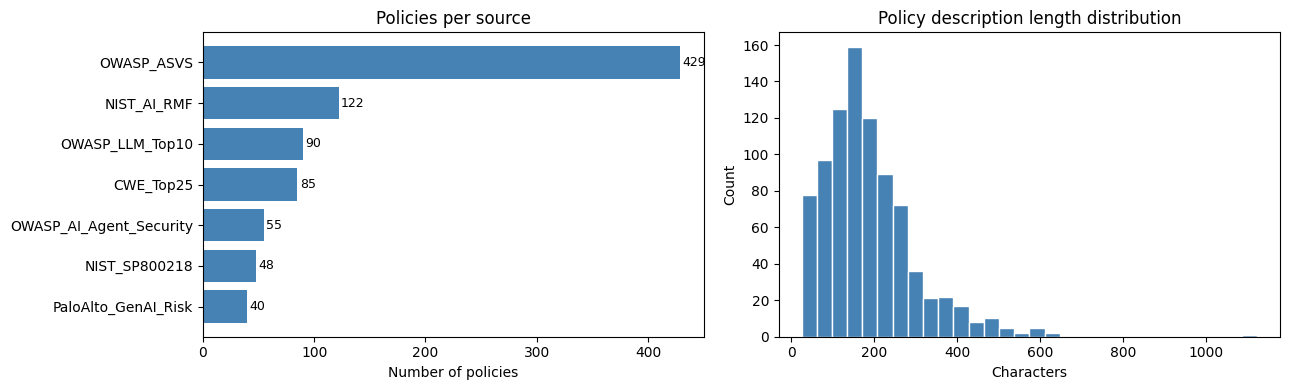

Chart saved → ../extracted/policy_stats.png


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — policies per source
src_counts = df["source"].value_counts()
axes[0].barh(src_counts.index, src_counts.values, color="steelblue")
axes[0].set_xlabel("Number of policies")
axes[0].set_title("Policies per source")
axes[0].invert_yaxis()
for i, v in enumerate(src_counts.values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)

# Histogram — description length distribution
axes[1].hist(desc_len, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].set_title("Policy description length distribution")

plt.tight_layout()
plt.savefig(EXTRACTED_DIR / "policy_stats.png", dpi=120)
plt.show()
print(f"Chart saved → {EXTRACTED_DIR / 'policy_stats.png'}")

## 4. Sample policies

In [6]:
# Show 2 sample policies per source
for src, group in df.groupby("source"):
    print(f"\n{'='*60}")
    print(f"  {src}  ({len(group)} policies)")
    print(f"{'='*60}")
    for _, row in group.head(2).iterrows():
        print(f"  scope      : {row['scope']}")
        print(f"  description: {row['policy_description'][:200]}")
        print(f"  reference  : {row['reference']}")
        print()


  CWE_Top25  (85 policies)
  scope      : Architecture and Design
  description: Consider using language-theoretic security (LangSec) techniques that characterize inputs using a formal language and build recognizers for that language.
  reference  : ['CWE-20', 'REF-1109', 'REF-1110', 'REF-1111']

  scope      : Architecture and Design
  description: Use an input validation framework such as Struts or the OWASP ESAPI Validation API.
  reference  : ['CWE-20']


  NIST_AI_RMF  (122 policies)
  scope      : NIST
  description: NIST will review the content and usefulness of the Framework regularly to determine if an update is appropriate; a review with formal input from the AI community is expected to take place no later tha
  reference  : ['UpdateScheduleandVersions', 'Page 3']

  scope      : AI RMF maintainers / NIST
  description: The Framework will employ a two-number versioning system to track and identify major and minor changes.
  reference  : ['UpdateScheduleandVersions', 'Page 3'